# End-to-end forecasting with skforecast-ai, fast path

## What is skforecast-ai?

[**skforecast**](https://skforecast.org) is a Python library for time series forecasting using scikit-learn compatible models, statistical methods, and foundation models. It gives you the building blocks (forecasters, backtesting, feature engineering, hyperparameter search) but leaves the many design decisions (which forecaster? which lags? how to validate?) up to you.

**skforecast-ai** is an assistant built **on top of skforecast** that helps automate, inspect, and explain forecasting workflows. It is organized around a single object, the `ForecastingAssistant`, with two complementary parts:

- **Deterministic engine (rule-based, reproducible).** It profiles the data, selects a forecaster and estimator, derives lags and preprocessing, runs backtesting, and produces the final forecast, together with the **exact standalone skforecast script** that generated the results. For the same inputs and configuration, this workflow is designed to be reproducible.

- **Optional LLM support.** The `ask()` method explains the objects and results you pass to it: profiles, plans, validation choices, backtesting outputs, forecasts, or general forecasting questions. In `ask()`, the LLM interprets existing information, it does not rerun the workflow or silently change the recommendation. Agentic features such as LLM-guided `refine_plan()` or `create_cv()` are separate, explicit steps where the LLM can suggest changes that are then implemented in deterministic code.

<p style="font-size:1.17em; font-weight:600; margin:1em 0; line-height:1.25;">Deterministic first, LLM where it helps</p>

The library is built around a practical split: forecasting decisions should be inspectable and reproducible, while natural-language explanations can be optional. The deterministic methods produce the configuration, results, and code. The LLM layer is useful when you want help understanding why a choice was made, how to read a backtest, or what a forecast implies.

That means you can run the full workflow without an LLM. If you do use one, it is mainly there to explain the artifacts produced by the workflow, or to support explicit agentic steps.

## Two ways to use skforecast-ai

`skforecast-ai` supports two ways of working with the same forecasting engine.

+ Use the **fast path** when you want a forecast or backtest result in a single call. The assistant profiles the data, builds the plan, runs the workflow, and returns the results together with the reproducible **skforecast** code.

+ Use the **step-by-step path** when you want to inspect or adjust the intermediate decisions. Create a profile, build a plan, optionally refine it, define a validation strategy, evaluate the model, and then generate the forecast.

A useful distinction is that forecasting and validation are separate branches. Once you have a `profile` and a `plan`, `forecast()` can produce future predictions directly and `backtest()` can evaluate the model on historical data.

You can call `ask()` in either workflow. It can explain a profile, a plan, a validation setup, a backtest result, a forecast result, or answer a general forecasting question. These calls are explanatory: they help interpret the current object or result, but they do not execute the workflow or silently modify the recommendation.

<div style="box-sizing:border-box; margin:16px 0; font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; color:#24292f; max-width:100%;">
  <div style="box-sizing:border-box; display:flex; gap:20px; flex-wrap:wrap; align-items:stretch;">

<!-- Fast path -->
<div style="box-sizing:border-box; flex:1 1 260px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#0969da; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Fast path &mdash; one call</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Profiling, planning and execution happen internally.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:18px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

<!-- Step-by-step path -->
<div style="box-sizing:border-box; flex:1.6 1 340px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#1a7f37; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Step-by-step path &mdash; full control</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Build a <code>profile</code> and a <code>plan</code> from your data, then branch into forecasting and backtesting.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:8px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">profile()</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">plan()<br><span style="font-weight:400; font-size:12px; color:#57606a;">refine_plan(), optional (Deterministic or Agentic mode)</span></div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

  </div>

  <!-- ask() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #8250df; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#8250df; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">ask() &mdash; available at any moment, in any workflow</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#faf5ff; font-size:13px;">Call <code>ask()</code> before, during or after either path. It can take a <code>profile</code>, a <code>plan</code>, a <code>forecast_result</code>, a <code>backtest_result</code>, or nothing at all (pure Q&amp;A). It only explains, it never changes a recommendation.</div>
  </div>
</div>

<div role="note"
     style="background: rgba(0,184,212,.08); border-left: 6px solid #00b8d4; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">
  <p style="display: flex; align-items: center; font-size: 1rem; color: #00b8d4; margin: 0 0 6px 0; font-weight: 600;">
    <span style="margin-right: 6px; font-size: 1.125em;">✏️</span>
    <strong style="font-size: 18px;">Note</strong>
  </p>

  <p>
    Both paths use the same deterministic workflow and return reproducible <strong>skforecast</strong> code. The step-by-step path additionally exposes intermediate objects, such as <code>profile</code>, <code>plan</code>, and <code>cv</code>, so you can inspect them or adjust them before running the next step.
  </p>
  
</div>

This example walks through the **fast path** of `skforecast-ai`: the quickest way to go from raw data to a validated forecast with minimal setup. It is ideal when you want results fast and trust the assistant to make sensible modeling decisions on your behalf. If you would rather understand what happens under the hood, step by step, visit the [the step-by-step path](forecasting-time-series-with-skforecast-ai-step-by-step.ipynb) for a more detailed walkthrough.

## Setup

In [1]:
# Data processing
# ==============================================================================
import os
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
from skforecast.plot import set_dark_theme
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# skforecast and skforecast-ai
# ==============================================================================
import skforecast
import skforecast_ai
from skforecast_ai import ForecastingAssistant
from skforecast.model_selection import TimeSeriesFold

color = '\033[1m\033[38;5;208m' 
print(f"{color}Version skforecast_ai: {skforecast_ai.__version__}")
print(f"{color}Version skforecast: {skforecast.__version__}")

Version skforecast_ai: 0.1.0
Version skforecast: 0.23.0


This tutorial uses a single `ForecastingAssistant` instance with an LLM configured, `assistant`. We use it for the entire workflow: profiling, planning, backtesting, and forecasting, as well as for the cells that call `ask()` and for the optional LLM-guided `refine_plan()` and `create_cv()` examples.

The LLM is configured with a string in the form `'provider:model_name'`, for example `'openai:gpt-5.5'`, `'google:gemini-3-flash-preview'`, `'anthropic:claude-sonnet-5'`, or `'ollama:qwen3:8b'`. For hosted providers, the corresponding API key must be available through the environment or passed explicitly when creating the assistant. In this tutorial, `send_data_to_llm=False`, so the LLM receives metadata and summary statistics, but not the raw time series values.

<div role="note"
     style="background: rgba(0,184,212,.08); border-left: 6px solid #00b8d4; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">
  <p style="display: flex; align-items: center; font-size: 1rem; color: #00b8d4; margin: 0 0 6px 0; font-weight: 600;">
    <span style="margin-right: 6px; font-size: 1.125em;">✏️</span>
    <strong style="font-size: 18px;">Note</strong>
  </p>

  <p>
    If you do not have access to an LLM assistant, you can still follow the full tutorial using only the deterministic methods. Profiling, planning, backtesting, and forecasting all run without an LLM. Only the <code>ask()</code> explanations and the LLM-guided variants of <code>refine_plan()</code> and <code>create_cv()</code> require a configured assistant; their deterministic counterparts (for example, <code>refine_plan()</code> with explicit overrides and <code>prompt=None</code>) work without one.
  </p>
  
</div>

In [2]:
# LLM-enabled assistant
# ==============================================================================
LLM_MODEL = "google:gemini-3-flash-preview"
api_key = os.getenv("GOOGLE_API_KEY")

assistant = ForecastingAssistant(
    llm=LLM_MODEL, api_key=api_key, send_data_to_llm=False
)

# Deterministic assistant (no LLM required)
# Use this assistant if you do not have access to an LLM or do not want to use one. 
# It will run the workflow deterministically, without any LLM guidance.
# ==============================================================================
# assistant = ForecastingAssistant()

## Data

The data in this document represent the hourly usage of the bike share system in the city of Washington, D.C. during the years 2011 and 2012. In addition to the number of users per hour, information about weather conditions and holidays is available. The original data was obtained from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset) and has been previously cleaned ([code](https://github.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/blob/master/code/prepare_bike_sharing_dataset.ipynb)) applying the following modifications:

+ Renamed columns with more descriptive names.

+ Renamed categories of the weather variables. The category of `heavy_rain` has been combined with that of `rain`.

+ Denormalized temperature, humidity and wind variables.

+ `date_time` variable created and set as index.

+ Imputed missing values by forward filling.

<div role="note"
     style="background: rgba(0,184,212,.08); border-left: 6px solid #00b8d4; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">
  <p style="display: flex; align-items: center; font-size: 1rem; color: #00b8d4; margin: 0 0 6px 0; font-weight: 600;">
    <span style="margin-right: 6px; font-size: 1.125em;">✏️</span>
    <strong style="font-size: 18px;">Note</strong>
  </p>

  <p>
    <code>skforecast-ai</code> is ready to preprocess the data, but it is recommended that users apply their own preprocessing steps before using the assistant. This ensures the data is in the desired format and any necessary transformations have been applied before proceeding with the forecasting workflow.
  </p>
  
</div>

In [3]:
# Downloading data
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users,holiday,weather,temp
0,2011-01-01 00:00:00,16.0,0.0,clear,9.84
1,2011-01-01 01:00:00,40.0,0.0,clear,9.02
2,2011-01-01 02:00:00,32.0,0.0,clear,9.02
3,2011-01-01 03:00:00,13.0,0.0,clear,9.84
4,2011-01-01 04:00:00,1.0,0.0,clear,9.84


In [4]:
# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=data['date_time'], y=data['users'], mode='lines', name='Train')
)
fig.update_layout(
    title  = 'Number of users',
    xaxis_title="Time",
    yaxis_title="Users",
    legend_title="Partition:",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
fig.show()

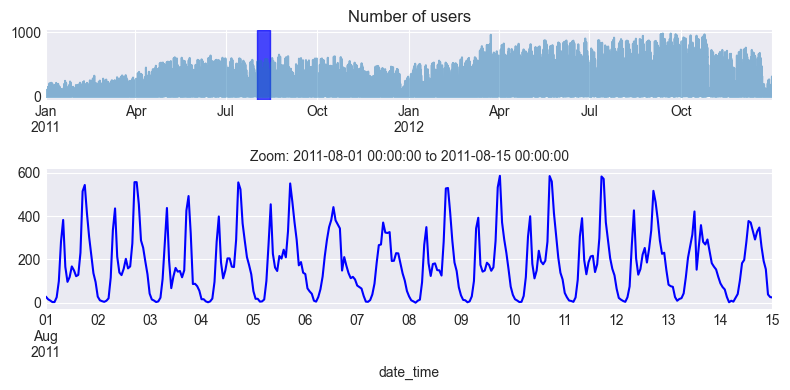

In [5]:
# Static plot of time series with zoom
# ==============================================================================
data_plot = data.copy()
data_plot['date_time'] = pd.to_datetime(data_plot['date_time'], format='%Y-%m-%d %H:%M:%S')
data_plot = data_plot.set_index('date_time')

zoom = ('2011-08-01 00:00:00', '2011-08-15 00:00:00')
fig, axs = plt.subplots(2, 1, figsize=(8, 4), gridspec_kw={"height_ratios": [1, 2]})
data_plot['users'].plot(ax=axs[0], label='users', alpha=0.5)
axs[0].axvspan(zoom[0], zoom[1], color="blue", alpha=0.7)
axs[0].set_title("Number of users")
axs[0].set_xlabel("")
# Zoom plot
data_plot.loc[zoom[0] : zoom[1], "users"].plot(ax=axs[1], color="blue")
axs[1].set_title(f"Zoom: {zoom[0]} to {zoom[1]}", fontsize=10)
plt.tight_layout()
plt.show()

For a deeper walkthrough of the exploratory analysis behind this dataset, see the skforecast example: [Forecasting time series with skforecast, XGBoost, LightGBM and CatBoost](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost#Data_exploration).

## Fast path

The fast path is the simplest way to get a forecast or backtest result. It runs the deterministic workflow in a single call, returning the results and the reproducible **skforecast** code that generated them.

### One-shot forecast

`forecast()` is the fast-path entry point: from a single call it runs the full profile → plan → execute pipeline and returns a `ForecastResult` holding the predictions, the evaluation metrics (when available), and the exact standalone **skforecast** script that produced them.

The behaviour is controlled by a single switch, `test_size`, which selects one of two modes:

+ **Evaluation mode** (`test_size` is set). The dataset is split into train and test sets, the model is trained on the training portion, and predictions for the test window are compared against the held-out actuals to compute metrics. In this mode the test-set exogenous values are taken from the split, so `exog` must not be passed.

+ **Prediction mode** (`test_size = None`, the default). The model is trained on the entire dataset and forecasts the next `steps` time points into the future. No metrics are returned, there is no ground truth to compare against. If the data contains exogenous variables, their future values must be supplied through `exog`.

The main arguments:

| Argument | Type | Description |
|---|---|---|
| `data` | Series, DataFrame, str, Path | Input dataset or path to a CSV file. When a `Series` is passed, the target is taken from its name. |
| `steps` | int | Forecast horizon (number of steps ahead to predict). |
| `target` | str, list of str | Column to forecast. Optional when `data` is a `Series`. Pass a list of column names for wide-format multi-series. |
| `date_column` | str | Column holding the timestamps. When `None`, the index of `data` must already be a `DatetimeIndex`. |
| `exog` | DataFrame | Future exogenous values covering the horizon (at least `steps` rows). Used only in prediction mode, and required there when the data has exogenous variables. |
| `interval` | list of float | Prediction interval as `[lower, upper]` quantiles (e.g. `[0.1, 0.9]` for an 80% interval). `None` disables intervals. |
| `test_size` | int, float, str, Timestamp | Size or start of the test set, selecting the mode above. `int`: last `test_size` observations; `float` in `(0, 1)`: last fraction of observations; `str`/`Timestamp`: first timestamp of the test set. `None` runs prediction mode. |

<div role="note"
    style="background: rgba(0,191,191,.08); border-left: 6px solid #00bfa5;
        border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#00bfa5;
        margin:0 0 6px 0; font-weight:600;">
<span style="margin-right:6px; font-size:18px;">💡</span>
<strong style="margin-right:6px; font-size:18px;">Tip</strong>
</p>

<p>

You can also use custom configurations for the <code>forecaster</code>, <code>estimator</code>, <code>estimator_kwargs</code>, <code>lags</code>, and <code>window_features</code> by passing them as arguments to <code>forecast()</code>. This allows you to override the assistant's automatic choices and use your own preferred settings.

For example, this code specifies a custom forecaster while still letting the assistant handle the rest of the workflow:

```python
results = assistant.forecast(
              data        = data,
              target      = 'users',
              date_column = "date_time",
              steps       = 36,
              forecaster  = 'ForecasterFoundation'
          )
```

</p>

</div>

#### Evaluation mode

In [6]:
# Hold out the last 36 hours as the test set
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]

results_eval = assistant.forecast(
                   data        = data,
                   target      = 'users',
                   date_column = "date_time",
                   steps       = 36,
                   interval    = [0.1, 0.9],  # 80% prediction interval
                   test_size   = 36           # Last 36 hours as test set (evaluation mode)
               )

display(results_eval.metrics)
display(results_eval.predictions.head())

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,series,MAE,MSE,MASE,MAPE
0,users,32.013374,2758.8615,0.497185,0.415688


,pred,lower_bound,upper_bound
2012-12-30 12:00:00,146.512223,111.097550,181.185404
2012-12-30 13:00:00,138.768717,96.950185,178.804105
2012-12-30 14:00:00,145.133323,92.701496,185.332563
2012-12-30 15:00:00,140.891323,89.525337,185.272888
2012-12-30 16:00:00,139.538959,86.994814,180.904345


In [7]:
# skforecast code that generated the results
# ==============================================================================
results_eval.show_code()

╭──────────────────────────────────────────────── Generated code ─────────────────────────────────────────────────╮
│ import pandas as pd                                                                                             │
│ from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error             │
│ from skforecast.metrics import mean_absolute_scaled_error                                                       │
│ from lightgbm import LGBMRegressor                                                                              │
│ from skforecast.preprocessing import RollingFeatures, CalendarFeatures                                          │
│ from skforecast.recursive import ForecasterRecursive                                                            │
│                                                                                                                 │
│ # Load data                                                                                                     │
│ data = pd.read_csv('data.csv')                                                                                  │
│                                                                                                                 │
│ data['date_time'] = pd.to_datetime(data['date_time'])                                                           │
│ data = data.set_index('date_time')                                                                              │
│ data = data.asfreq('h')                                                                                         │
│ data = data.sort_index()                                                                                        │
│                                                                                                                 │
│ # Train/test split                                                                                              │
│ end_train = '2012-12-30 11:00:00'  # last training date, adjust to change the split point                       │
│ data_train = data.loc[:end_train]                                                                               │
│ data_test  = data.loc[data.index > end_train]                                                                   │
│ exog_features = ['holiday', 'weather', 'temp']                                                                  │
│                                                                                                                 │
│ print(                                                                                                          │
│     f"Train dates : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})"               │
│ )                                                                                                               │
│ print(                                                                                                          │
│     f"Test dates  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})"                  │
│ )                                                                                                               │
│                                                                                                                 │
│ window_features = RollingFeatures(                                                                              │
│     stats        = ['mean', 'std', 'mean', 'mean'],                                                             │
│     window_sizes = [3, [38;2;174;129;255;48;2;3

#### Prediction mode

In [8]:
# Forecast the next 36 hours using the entire dataset (prediction mode)
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]

# Simulate future values of exogenous variables for the next 36 hours
exog = data[['holiday', 'weather', 'temp']].tail(36).copy()
exog.index = pd.date_range(
    start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(hours=1), periods=36, freq='h'
)

results_pred = assistant.forecast(
                   data        = data,
                   target      = 'users',
                   date_column = "date_time",
                   steps       = 36,
                   interval    = [0.1, 0.9],  # 80% prediction interval
                   test_size   = None,        # Use the entire dataset for training (prediction mode)
                   exog        = exog         # Future values of exogenous variables for the next 36 hours
               )

# No metrics are returned, no data to compare against
# display(results_pred.metrics)

display(results_pred.predictions.head())

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,pred,lower_bound,upper_bound
2013-01-01 00:00:00,27.442927,11.127479,47.557452
2013-01-01 01:00:00,13.318240,3.310496,27.242435
2013-01-01 02:00:00,9.208553,2.380079,19.120340
2013-01-01 03:00:00,5.329501,0.570137,10.013675
2013-01-01 04:00:00,5.979160,1.305255,10.265962


In [9]:
# skforecast code that generated the results
# ==============================================================================
results_pred.show_code()

╭──────────────────────────────────────────────── Generated code ─────────────────────────────────────────────────╮
│ import pandas as pd                                                                                             │
│ from lightgbm import LGBMRegressor                                                                              │
│ from skforecast.preprocessing import RollingFeatures, CalendarFeatures                                          │
│ from skforecast.recursive import ForecasterRecursive                                                            │
│                                                                                                                 │
│ # Load data                                                                                                     │
│ data = pd.read_csv('data.csv')                                                                                  │
│                                                                                                                 │
│ # Load future exogenous variables covering the forecast horizon                                                 │
│ exog_future = pd.read_csv('exog_future.csv')                                                                    │
│                                                                                                                 │
│ data['date_time'] = pd.to_datetime(data['date_time'])                                                           │
│ data = data.set_index('date_time')                                                                              │
│ data = data.asfreq('h')                                                                                         │
│ data = data.sort_index()                                                                                        │
│                                                                                                                 │
│ exog_future['date_time'] = pd.to_datetime(exog_future['date_time'])                                             │
│ exog_future = exog_future.set_index('date_time')                                                                │
│ exog_future = exog_future.asfreq('h')                                                                           │
│ exog_future = exog_future.sort_index()                                                                          │
│                                                                                                                 │
│ exog_features = ['holiday', 'weather', 'temp']                                                                  │
│                                                                                                                 │
│ window_features = RollingFeatures(                                                                              │
│     stats        = ['mean', 'std', 'mean', 'mean'],                                                             │
│     window_sizes = [3, 3, 24, 168],                                                                             │
│ )                                                                                                               │
│                                                                                                                 │
│ calendar_features = CalendarFeatures(                                                                           │
│     features = ['hour', 'day_of_week', 'weekend', 'month'],                                                     │
│     encoding = None,                                                                                            │
│ )                                                                                                               │
│                                                                                                                 │
│ # Create forecaster                           

#### Asking the assistant about the forecast

After running the workflow, you can ask the assistant to explain the results. The `ask()` method can take a `ForecastResult` object and provide insights about the forecast, the metrics, or any other relevant information.

In [10]:
# Asking the assistant about the forecast results
# ==============================================================================
explanation = assistant.ask(
    prompt = "Explain the results of the forecast, including the metrics and predictions.",
    forecast_result = results_pred
)

In [11]:
# Show the explanation generated by the LLM
# ==============================================================================
explanation.show_explanation()

╭────────────────────────────────────────────────── Explanation ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Based on the pre-computed forecasting plan and results, here is an explanation of the forecast strategy and    │
│  the resulting predictions.                                                                                     │
│                                                                                                                 │
│  Strategy and Model Configuration                                                                               │
│                                                                                                                 │
│  The forecasting plan utilized a ForecasterRecursive with a LightGBM (LGBMRegressor) estimator. This approach   │
│  is highly effective for a dataset of this size (17,544 hourly observations) because gradient boosting models   │
│  excel at capturing non-linear patterns and complex seasonalities.                                              │
│                                                                                                                 │
│   • Feature Engineering: The model uses a sophisticated set of features:                                        │
│      • Lags: A specific selection of lags reaching back 337 hours (approx. 2 weeks) to capture immediate        │
│        dependencies and weekly cycles.                                                                          │
│      • Window Features: Rolling averages and standard deviations (3h, 24h, and 168h) allow the model to adapt   │
│        to recent trends and volatility shifts.                                                                  │
│      • Exogenous Variables: Information such as temperature and weather (automatically encoded) were included,  │
│        as they are often associated with changes in user activity.                                              │
│      • Calendar Features: Time-based variables like the hour of the day and day of the week were extracted to   │
│        help the model learn daily and weekly routines.                                                          │
│                                                                                                                 │
│  Evaluation Metrics                                                                                             │
│                                                                                                                 │
│  As this task was performed in prediction mode without available ground-truth data for the forecast horizon,    │
│  no evaluation metrics (such as MAE or RMSE) were computed for this specific output.                            │
│                                                                                                                 │
│  However, the plan identified Mean Absolute Error (MAE) as the primary metric for future validation. MAE was    │
│  selected because it is highly interpretable—representing the average error in the same units as the "users"    │
│  target—and is robust to outliers, ensuring that occasional unusual spikes in user activity do not              │
│  disproportionately skew the model's performance evaluation.                                                    │
│                                                                                                                 │
│  Forecast Analysis                                                                                              │
│                                                                                                                 │
│  The model provided a 36-hour forecast starting from January 1st, 2013.                                         │
│                                                       

#### Enhancing the forecast with a prompt

Beyond explaining results, the assistant can also help you **improve them**. The `refine_plan()` method takes an existing `profile` and `plan` and returns an updated `ForecastPlan`. It works in two modes:

- **Deterministic mode** (no `prompt`): you pass explicit overrides such as `forecaster`, `estimator`, `estimator_kwargs`, `steps`, `interval`, `lags`, or `window_features`. Only the fields you override change; everything else is re-derived deterministically from the original plan.

- **LLM mode** (`prompt` provided): a specialized agent reads your natural-language domain knowledge and suggests new `lags` and `window_features`, which are merged on top of the deterministic plan. The agent's reasoning is appended to the returned plan's `explanation`, so you can trace why each change was made.

In the example below we use LLM mode: we ask for better lags and window features, then re-run `forecast()` with the refined plan and compare the metrics against the original run.

Keep in mind that a refined plan is a **hypothesis, not a guaranteed improvement**. The LLM proposes lags and window features from the domain knowledge you provide, but only a proper evaluation can confirm whether they actually help. Always backtest the refined plan against the original before adopting it, and check that the suggested features are sensible for your data and use case rather than trusting them blindly.

In [12]:
# Ask the assistant to improve the forecast accuracy
# ==============================================================================
prompt  = (
    "I'm forecasting hourly bike rentals. Demand follows a clear daily rhythm with "
    "rush-hour peaks, and it changes between weekdays and weekends. It's also usually "
    "similar to what happened at the same time last week, and the last few hours give "
    "a good sense of the current trend. Please pick lags and rolling features that fit this."
)

refined_plan = assistant.refine_plan(
                   profile = results_pred.profile,
                   plan    = results_pred.plan,
                   prompt  = prompt
               )

In [13]:
# Refined plan proposed by the assistant
# ==============================================================================
refined_plan

                                                   Forecast Plan                                                   
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                                                       ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Forecaster        │ ForecasterRecursive                                                                         │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                                               │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                                          │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                                           │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 23, 24, 25, 167, 168, 169]  (LLM-suggested)                                       │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 6}, {'stats': ['mean'], 'window_size': 24},      │
│                   │ {'stats': ['mean'], 'window_size': 168}]  (LLM-suggested)                                   │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding)                          │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                                                        │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                                                  │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                                               │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                                         │
├───────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │   - handle_categorical_exog: Categorical exogenous variables detected: ['weather']. These   │
│                   │ are handled automatically by skforecast (categorical_features='auto').                      │
└───────────────────┴─────────────────────────────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────────────────── Plan Explanation ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 23, 24, 25, 167, 168, 169]. Window features:        │
│  ['mean(window=6)', 'std(window=6)', 'mean(window=24)', 'mean(window=168)']. Calendar features: ['hour',        │
│  'day_of_week', 'weekend', 'month'] (raw ordinal enco

In [ ]:
# Run the forecast with the refined plan 
# ==============================================================================
results_refined = assistant.forecast(
                      data        = data,
                      target      = 'users',
                      date_column = "date_time",
                      steps       = 36,
                      test_size   = 36,           # Last 36 hours as test set (evaluation mode)
                      plan        = refined_plan  # Refined plan proposed by the assistant
                  )

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:389                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [15]:
# Results of the forecast with the refined plan
# ==============================================================================
results_refined.metrics

,series,MAE,MSE,MASE,MAPE
0,users,48.184141,5033.961737,0.748326,0.529829


In [16]:
# Results of the forecast with the original plan
# ==============================================================================
results_eval.metrics

,series,MAE,MSE,MASE,MAPE
0,users,32.013374,2758.8615,0.497185,0.415688


In [17]:
# Refined forecaster arguments (lags and window features proposed by the LLM)
# ==============================================================================
results_refined.plan.forecaster_kwargs

{'lags': [1, 2, 3, 23, 24, 25, 167, 168, 169],
 'window_features': [{'stats': ['mean', 'std'], 'window_size': 6},
  {'stats': ['mean'], 'window_size': 24},
  {'stats': ['mean'], 'window_size': 168}],
 'calendar_features': {'features': ['hour', 'day_of_week', 'weekend', 'month'],
  'encoding': None},
 'categorical_features': 'auto',
 'dropna_from_series': False}

In [18]:
# Original forecaster arguments (deterministic lags and window features)
# ==============================================================================
results_eval.plan.forecaster_kwargs

{'lags': [1,
  2,
  3,
  5,
  8,
  10,
  15,
  17,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  32,
  33,
  119,
  121,
  135,
  136,
  142,
  143,
  145,
  160,
  166,
  167,
  169,
  313,
  335,
  337],
 'window_features': [{'stats': ['mean', 'std'], 'window_size': 3},
  {'stats': ['mean'], 'window_size': 24},
  {'stats': ['mean'], 'window_size': 168}],
 'calendar_features': {'features': ['hour', 'day_of_week', 'weekend', 'month'],
  'encoding': None},
 'categorical_features': 'auto',
 'dropna_from_series': False}

As noted above, a refined plan is a hypothesis, not a guaranteed improvement. The LLM may propose lags or window features that are not relevant to the series, or it may misread the domain knowledge you provided, so the refined plan can perform worse than the original.

More importantly, here we evaluate the change on a single 36-hour test window, which is far too small to draw a reliable conclusion. A single split can favor either plan by chance. To decide whether the refinement genuinely helps, evaluate both plans with a backtest over multiple folds (see the next section), which averages performance across many test windows and gives a far more trustworthy comparison.

#### The `ForecastResult` object

Both modes return a `ForecastResult`, a lightweight container that bundles everything the assistant used and produced, so you can inspect the outputs, audit the decisions, or lift the code straight into production.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Forecasted values for the requested steps. When intervals (or quantiles) are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame, None | Evaluation metrics (`MAE`, `MSE`, `MASE`), one row per series. `None` in prediction mode, where there is no ground truth to score against. |
| `code` | str | The exact standalone **skforecast** script that produced the forecast, deterministic and ready to run on its own. |
| `profile` | `ForecastingProfile` | The data profile behind the forecast: metadata, summary statistics, detected frequency and seasonality, and the high-level modeling decisions. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed: forecaster, estimator, lags, window features, preprocessing, and interval settings. |

Displaying the object in a notebook renders a rich summary of all of the above; the raw script is also available through `results.show_code()`.

In [19]:
# Full results object
# ==============================================================================
print(type(results_eval))
results_eval

<class 'skforecast_ai.schemas.results.ForecastResult'>


              Dataset Profile              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                 │
├────────────────┼────────────────────────┤
│ Series         │ 1                      │
├────────────────┼────────────────────────┤
│ Observations   │ 17544                  │
├────────────────┼────────────────────────┤
│ Frequency      │ h                      │
├────────────────┼────────────────────────┤
│ Target         │ users                  │
├────────────────┼────────────────────────┤
│ Exog columns   │ holiday, weather, temp │
├────────────────┼────────────────────────┤
│ Missing target │ none                   │
└────────────────┴────────────────────────┘

                                             Recommendation                                             
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                                        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                                                │
├───────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                                          │
├───────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation, ForecasterStats │
├───────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                                                │
├───────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                                           │
└───────────────────────┴──────────────────────────────────────────────────────────────────────────────┘

╭────────────────────────────────────────────────── Explanation ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544 observations, 'h' frequency.   │
│  Alternative forecasters: ['ForecasterDirect', 'ForecasterFoundation', 'ForecasterStats']. Estimator:           │
│  LGBMRegressor. A gradient boosting model is preferred for a dataset of this size (17544 observations).         │
│  Alternative estimators: ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as          │
│  predictors.                                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
                                                   Forecast Plan                                                   
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                                                       ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Forecaster        │ ForecasterRecursive                                                                         │
├───────────────────┼───────────────────────────────────────────────────────────────────────────────────────────

### One-shot backtest

In time series forecasting, the process of *backtesting* consists of **evaluating the performance of a predictive model by applying it retrospectively to historical data**. Therefore, it is a special type of cross-validation applied to the previous period(s).

The reliability of backtesting results depends on how well the setup mirrors the real-world use case. The closer the backtesting process is to the actual conditions under which the model will operate, including prediction horizon, refit frequency, and data availability, the more trustworthy the estimated performance metrics will be.

The **`TimeSeriesFold`** defines *how* the historical data is split into successive train and test windows: the forecast horizon (`steps`), where the first evaluation starts (`initial_train_size`), whether the model is retrained as the window rolls forward (`refit`), among other parameters. Because these choices determine what the reported metrics actually mean, getting the `TimeSeriesFold` right is the most important decision of the whole evaluation. For a detailed explanation of these concepts, see the skforecast [Backtesting user guide](https://skforecast.org/latest/user_guides/backtesting).

`skforecast-ai` gives you three ways to obtain this object, from full manual control to fully delegated:

+ **Provide your own `TimeSeriesFold`** *(recommended)*. When you already know how the model will be used in production, build the fold yourself and pass it to `backtest()`. This is the most explicit and reproducible option, and it keeps the validation setup entirely under your control.

+ **`create_cv()` with a prompt** *(requires an LLM)*. Describe your use case in natural language (horizon, how often you can retrain, how much history you trust) and let the LLM translate that context into `TimeSeriesFold` settings, which are then materialized in deterministic code.

+ **`create_cv()` in deterministic mode.** Let the assistant derive a sensible `TimeSeriesFold` from the `profile` and `plan` using rule-based defaults (no LLM required). You can still override individual arguments such as `initial_train_size` or `refit`.

The example below uses the recommended approach: we build a `TimeSeriesFold` explicitly and hand it to `backtest()`.


In [ ]:
# Hold out the last 36 hours as the test set
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]

# Create your own TimeSeriesFold object
end_train = '2012-08-31 23:59:00'
cv = TimeSeriesFold(
         steps              = 36, 
         initial_train_size = end_train, 
         refit              = False
     )

results_backtest = assistant.backtest(
                       data        = data,
                       target      = 'users',
                       date_column = "date_time",
                       cv          = cv,          # TimeSeriesFold object
                       interval    = [0.1, 0.9],  # 80% prediction interval
                   )

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

Information of folds
--------------------
Number of observations used for initial training: 14616
Number of observations used for backtesting: 2928
    Number of folds: 82
    Number skipped folds: 0 
    Number of steps per fold: 36
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 12 observations.

Fold: 0
    Training:   2011-01-01 00:00:00 -- 2012-08-31 23:00:00  (n=14616)
    Validation: 2012-09-01 00:00:00 -- 2012-09-02 11:00:00  (n=36)
Fold: 1
    Training:   No training in this fold
    Validation: 2012-09-02 12:00:00 -- 2012-09-03 23:00:00  (n=36)
Fold: 2
    Training:   No training in this fold
    Validation: 2012-09-04 00:00:00 -- 2012-09-05 11:00:00  (n=36)
Fold: 3
    Training:   No training in this fold
    Validation: 2012-09-05 12:00:00 -- 2012-09-06 23:00:00  (n=36)
Fold: 4
    Training:   No training in this fold
    Validation: 2012-09-07 00:00:00 -- 2012-09-08 11:00:00  (n=36)
Fold: 5
    Tr

  0%|          | 0/82 [00:00<?, ?it/s]

In [21]:
# Show backtest results
# ==============================================================================
results_backtest.show_explanation()
display(results_backtest.metrics)
display(results_backtest.predictions.head())

╭────────────────────────────────────────────────── Explanation ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon, 82 folds. Results —       │
│  mean_absolute_error: 46.3122, mean_squared_error: 5495.8816, mean_absolute_scaled_error: 0.7496,               │
│  mean_absolute_percentage_error: 0.4727.                                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,46.312218,5495.881638,0.749598,0.472735


,fold,pred,lower_bound,upper_bound
2012-09-01 00:00:00,0,124.163668,99.669766,149.384335
2012-09-01 01:00:00,0,96.989454,68.523139,127.651105
2012-09-01 02:00:00,0,65.894182,32.969786,97.883129
2012-09-01 03:00:00,0,29.961028,10.347714,60.808462
2012-09-01 04:00:00,0,9.103018,2.980393,28.085362


In [22]:
# Show backtest code
# ==============================================================================
results_backtest.show_code()

╭──────────────────────────────────────────────── Generated code ─────────────────────────────────────────────────╮
│ import pandas as pd                                                                                             │
│ from lightgbm import LGBMRegressor                                                                              │
│ from skforecast.preprocessing import RollingFeatures, CalendarFeatures                                          │
│ from skforecast.recursive import ForecasterRecursive                                                            │
│ from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster                                   │
│                                                                                                                 │
│ # Load data                                                                                                     │
│ data = pd.read_csv('data.csv')                                                                                  │
│                                                                                                                 │
│ data['date_time'] = pd.to_datetime(data['date_time'])                                                           │
│ data = data.set_index('date_time')                                                                              │
│ data = data.asfreq('h')                                                                                         │
│ data = data.sort_index()                                                                                        │
│                                                                                                                 │
│ window_features = RollingFeatures(                                                                              │
│     stats        = ['mean', 'std', 'mean', 'mean'],                                                             │
│     window_sizes = [3, 3, 24, 168],                                                                             │
│ )                                                                                                               │
│                                                                                                                 │
│ calendar_features = CalendarFeatures(                                                                           │
│     features = ['hour', 'day_of_week', 'weekend', 'month'],                                                     │
│     encoding = None,                                                                                            │
│ )                                                                                                               │
│                                                                                                                 │
│ # Create forecaster                                                                                             │
│ forecaster = ForecasterRecursive(                                                                               │
│     estimator            = LGBMRegressor(random_state=123, verbose=-1),                                         │
│     lags                 = [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32, 33, 119, 121, 135,   │
│ 136, 

#### Asking the assistant about the backtesting

After running the workflow, you can ask the assistant to explain the backtesting results. The `ask()` method can take a `BacktestResult` object and provide insights about the strategy, the metrics, or any other relevant information.

In [23]:
# Asking the assistant about the backtesting
# ==============================================================================
explanation = assistant.ask(
    prompt = "Explain the results of the backtesting, including the strategy, metrics, and predictions.",
    backtest_result = results_backtest
)

In [24]:
# Show the explanation generated by the LLM
# ==============================================================================
explanation.show_explanation()

╭────────────────────────────────────────────────── Explanation ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Based on the provided pre-computed results, here is an explanation of the backtesting strategy, the resulting  │
│  metrics, and the prediction characteristics.                                                                   │
│                                                                                                                 │
│  Backtesting Strategy                                                                                           │
│                                                                                                                 │
│  The evaluation used a non-refitting (train-once) strategy. This means the LGBMRegressor was trained a single   │
│  time using data up until August 31, 2012. Following this training:                                             │
│                                                                                                                 │
│   • Evaluation Horizon: The model generated forecasts in blocks of 36 hours (steps).                            │
│   • Folds: A total of 82 folds were evaluated, spanning from September 1, 2012, to December 31, 2012.           │
│   • Efficiency: Because refit=False, the model's performance was tested on its ability to generalize over a     │
│     four-month period without seeing new data, simulating a deployment where retraining happens infrequently.   │
│                                                                                                                 │
│  Metric Interpretation                                                                                          │
│                                                                                                                 │
│  The model’s performance is summarized by four primary metrics:                                                 │
│                                                                                                                 │
│   • MAE (46.31): On average, the predicted user count deviates from the actual value by approximately 46        │
│     users.                                                                                                      │
│   • MASE (0.75): This is the most critical metric for quality. Since the value is less than 1.0, the model is   │
│     significantly more accurate than a "naive" baseline (which simply predicts the previous hour's value). It   │
│     represents a 25% improvement over the baseline.                                                             │
│   • MAPE (47.27%): While this percentage appears high, it is common in time series with low-volume periods      │
│     (e.g., late-night hours). Small absolute errors during low-usage times result in high percentage errors,    │
│     making MAE and MASE more reliable indicators of performance here.                                           │
│   • MSE (5495.88): This metric penalizes larger errors more heavily. Given the mean prediction of 236 users,    │
│     this indicates that while the model is generally accurate, there may be occasional larger deviations        │
│     during peak usage.                                                                                          │
│                                                                                                                 │
│  Predictions and Uncertainty                                                                                    │
│                                                                                                                 │
│  The forecast includes an 80% prediction interval calculated via bootstrapping.                                 │
│                                                       

#### Creating the cv object with a prompt

Instead of hand-tuning `TimeSeriesFold` parameters yourself, you can describe your backtesting strategy in plain language and let the assistant translate it into a valid cross-validation configuration. Just profile your data, create a plan, and pass a prompt explaining how you want the model trained and validated (forecast horizon, training window, refit behavior, gaps, etc.). The assistant returns a ready-to-use `TimeSeriesFold` object along with an explanation of the choices it made, so you can verify the strategy before running the backtest.

In [ ]:
# Let the assistant create the TimeSeriesFold for you
# ==============================================================================

# Profile and create a plan for your data
profile = assistant.profile(data, target="users", date_column="date_time")
plan = assistant.plan(profile, steps=36)

# Call create_cv with a prompt that describes your prediction strategy
prompt = (
    "I forecast bike demand 36 hours ahead. "
    "The model should be trained once on all data up to the end of August 2012, 23:59. "
    "Do not refit the model as the window rolls forward."
)

cv, cv_explanation = assistant.create_cv(
                         profile = profile,
                         plan    = plan,
                         prompt  = prompt
                     )

In [26]:
# TimeSeriesFold object
# ==============================================================================
cv

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = False,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

In [27]:
# LLM Reasoning
# ==============================================================================
print(cv_explanation)

The user explicitly requested the training set end at August 2012, 23:59. Since the model should not be updated as the window moves forward, 'refit' is set to False. This configuration will evaluate the frozen model's performance on subsequent 36-hour windows. Initial training up to 2012-08-31 23:59:00, expanding window, no refit, 36-step horizon, 82 folds.


Since the `prompt` correctly describes the intended use case, the `cv` object returned by `create_cv()` is the same as the one we built manually above. However it was derived from a natural-language description rather than explicit parameters. The assistant also returns a `cv_explanation` string that details the choices it made. This allows you to verify that the resulting `TimeSeriesFold` matches your intended strategy.

#### The `BacktestResult` object

The backtesting workflow returns a `BacktestResult`, a lightweight container that bundles everything the assistant used and produced, so you can inspect the outputs, audit the decisions, or lift the code straight into production.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Full out-of-sample backtest predictions across all folds. When intervals (or quantiles) are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame | Backtesting metrics (`MAE`, `MSE`, `MASE`) returned by **skforecast**, one row per series, computed over the reserved test window. |
| `cv_config` | dict | The resolved `TimeSeriesFold` parameters (steps, initial train size, refit, gap, etc.), kept for full traceability of the validation strategy. |
| `code` | str | The exact standalone **skforecast** script that reproduces the backtesting workflow, deterministic and ready to run on its own. |
| `explanation` | str | A human-readable summary of the backtesting configuration and what the results mean. |
| `profile` | `ForecastingProfile` | The data profile behind the backtest: metadata, summary statistics, detected frequency and seasonality, and the high-level modeling decisions. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed: forecaster, estimator, lags, window features, preprocessing, and interval settings. |

Displaying the object renders a rich summary of all of the above; the raw script is also available through `results_backtest.show_code()`.

In [28]:
# Full results object
# ==============================================================================
print(type(results_backtest))
results_backtest

<class 'skforecast_ai.schemas.results.BacktestResult'>


╭────────────────────────────────────────────────── Explanation ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon, 82 folds. Results —       │
│  mean_absolute_error: 46.3122, mean_squared_error: 5495.8816, mean_absolute_scaled_error: 0.7496,               │
│  mean_absolute_percentage_error: 0.4727.                                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
       Cross-Validation Configuration       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter          ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps              │                  36 │
├────────────────────┼─────────────────────┤
│ initial_train_size │ 2012-08-31 23:59:00 │
├────────────────────┼─────────────────────┤
│ refit              │               False │
├────────────────────┼─────────────────────┤
│ fixed_train_size   │                True │
├────────────────────┼─────────────────────┤
│ gap                │                   0 │
├────────────────────┼─────────────────────┤
│ fold_stride        │                  36 │
├────────────────────┼─────────────────────┤
│ differentiation    │                None │
└────────────────────┴─────────────────────┘
                                             Backtest Metrics                                             
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ mean_absolute_error ┃ mean_squared_error ┃ mean_absolute_scaled_error ┃ mean_absolute_percentage_error ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│             46.3122 │          5495.8816 │                     0.7496 │                         0.4727 │
└─────────────────────┴────────────────────┴────────────────────────────┴────────────────────────────────┘
                    Backtest Predictions (2928 rows)                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Index               ┃    fold ┃     pred ┃ lower_bound ┃ upper_bound ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 2012-09-01 00:00:00 │  0.0000 │ 124.1637 │     99.6698 │    149.3843 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 01:00:00 │  0.0000 │  96.9895 │     68.5231 │    127.6511 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 02:00:00 │  0.0000 │  65.8942 │     32.9698 │     97.8831 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 03:00:00 │  0.0000 │  29.9610 │     10.3477 │     60.8085 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 04:00:00 │  0.0000 │   9.1030 │      2.9804 │     28.0854 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ ...                 │     ... │      ... │         ... │         ... │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 19:00:00 │ 81.0000 │ 145.8848 │     97.1293 │    180.5958 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 20:00:00 │ 81.0000 │ 103.3326 │     67.3546 │    140.2631 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 21:00:00 │ 81.0000 │  64.1944 │     33.2954 │     86.5947 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 22:00:00 │ 81.0000 │  46.9473 │     23.0095 │     64.8209 │
├─────────────────────┼─────────┼──────────┼─────────────

## Step-by-step path

This example walks through the **fast path** of `skforecast-ai`: the quickest way to go from raw data to a validated forecast with minimal setup. It is ideal when you want results fast and trust the assistant to make sensible modeling decisions on your behalf. If you would rather understand what happens under the hood, step by step, visit the [the step-by-step path](forecasting-time-series-with-skforecast-ai-step-by-step.ipynb) for a more detailed walkthrough.